In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ronadasakalesha/movierecommendationsystemdataset/MovieRecommendationSystem.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/kaggle/input/datasets/ronadasakalesha/movierecommendationsystemdataset/MovieRecommendationSystem.csv')

In [4]:
df.head()

,Movie_ID,Movie_Title,Movie_Genre,Movie_Language,Movie_Budget,Movie_Popularity,Movie_Release_Date,Movie_Revenue,Movie_Runtime,Movie_Vote,...,Movie_Homepage,Movie_Keywords,Movie_Overview,Movie_Production_House,Movie_Production_Country,Movie_Spoken_Language,Movie_Tagline,Movie_Cast,Movie_Crew,Movie_Director
0,1,Four Rooms,Crime Comedy,en,4000000,22.876230,09-12-1995,4300000,98.0,6.5,...,NaN,hotel new year's eve witch bet hotel room,It's Ted the Bellhop's first night on the job....,"[{""name"": ""Miramax Films"", ""id"": 14}, {""name"":...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]",Twelve outrageous guests. Four scandalous requ...,Tim Roth Antonio Banderas Jennifer Beals Madon...,"[{'name': 'Allison Anders', 'gender': 1, 'depa...",Allison Anders
1,2,Star Wars,Adventure Action Science Fiction,en,11000000,126.393695,25-05-1977,775398007,121.0,8.1,...,http://www.starwars.com/films/star-wars-episod...,android galaxy hermit death star lightsaber,Princess Leia is captured and held hostage by ...,"[{""name"": ""Lucasfilm"", ""id"": 1}, {""name"": ""Twe...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]","A long time ago in a galaxy far, far away...",Mark Hamill Harrison Ford Carrie Fisher Peter ...,"[{'name': 'George Lucas', 'gender': 2, 'depart...",George Lucas
2,3,Finding Nemo,Animation Family,en,94000000,85.688789,30-05-2003,940335536,100.0,7.6,...,http://movies.disney.com/finding-nemo,father son relationship harbor underwater fish...,"Nemo, an adventurous young clownfish, is unexp...","[{""name"": ""Pixar Animation Studios"", ""id"": 3}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]","There are 3.7 trillion fish in the ocean, they...",Albert Brooks Ellen DeGeneres Alexander Gould ...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton
3,4,Forrest Gump,Comedy Drama Romance,en,55000000,138.133331,06-07-1994,677945399,142.0,8.2,...,NaN,vietnam veteran hippie mentally disabled runni...,A man with a low IQ has accomplished great thi...,"[{""name"": ""Paramount Pictures"", ""id"": 4}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]","The world will never be the same, once you've ...",Tom Hanks Robin Wright Gary Sinise Mykelti Wil...,"[{'name': 'Alan Silvestri', 'gender': 2, 'depa...",Robert Zemeckis
4,5,American Beauty,Drama,en,15000000,80.878605,15-09-1999,356296601,122.0,7.9,...,http://www.dreamworks.com/ab/,male nudity female nudity adultery midlife cri...,"Lester Burnham, a depressed suburban father in...","[{""name"": ""DreamWorks SKG"", ""id"": 27}, {""name""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]",Look closer.,Kevin Spacey Annette Bening Thora Birch Wes Be...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4760 entries, 0 to 4759
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Movie_ID                  4760 non-null   int64  
 1   Movie_Title               4760 non-null   object 
 2   Movie_Genre               4760 non-null   object 
 3   Movie_Language            4760 non-null   object 
 4   Movie_Budget              4760 non-null   int64  
 5   Movie_Popularity          4760 non-null   float64
 6   Movie_Release_Date        4760 non-null   object 
 7   Movie_Revenue             4760 non-null   int64  
 8   Movie_Runtime             4758 non-null   float64
 9   Movie_Vote                4760 non-null   float64
 10  Movie_Vote_Count          4760 non-null   int64  
 11  Movie_Homepage            1699 non-null   object 
 12  Movie_Keywords            4373 non-null   object 
 13  Movie_Overview            4757 non-null   object 
 14  Movie_Pr

In [6]:
df.describe()

,Movie_ID,Movie_Budget,Movie_Popularity,Movie_Revenue,Movie_Runtime,Movie_Vote,Movie_Vote_Count
count,4760.000000,4.760000e+03,4760.000000,4.760000e+03,4758.000000,4760.000000,4760.000000
mean,2382.566387,2.920129e+07,21.599510,8.263743e+07,107.184111,6.113866,692.508403
std,1377.270159,4.075620e+07,31.887919,1.630554e+08,21.960332,1.141294,1235.007337
min,1.000000,0.000000e+00,0.000372,0.000000e+00,0.000000,0.000000,0.000000
25%,1190.750000,9.257500e+05,4.807074,0.000000e+00,94.000000,5.600000,55.000000
50%,2380.500000,1.500000e+07,13.119058,1.944716e+07,104.000000,6.200000,238.000000
75%,3572.250000,4.000000e+07,28.411929,9.341276e+07,118.000000,6.800000,740.250000
max,4788.000000,3.800000e+08,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


In [7]:
df.isnull().sum()

Movie_ID                       0
Movie_Title                    0
Movie_Genre                    0
Movie_Language                 0
Movie_Budget                   0
Movie_Popularity               0
Movie_Release_Date             0
Movie_Revenue                  0
Movie_Runtime                  2
Movie_Vote                     0
Movie_Vote_Count               0
Movie_Homepage              3061
Movie_Keywords               387
Movie_Overview                 3
Movie_Production_House         0
Movie_Production_Country       0
Movie_Spoken_Language          0
Movie_Tagline                818
Movie_Cast                    27
Movie_Crew                     0
Movie_Director                22
dtype: int64

# Data Cleaning

In [8]:
df.drop(columns = ['Movie_Homepage'],inplace = True)

In [9]:
features_to_clean = ['Movie_Keywords', 'Movie_Tagline', 'Movie_Cast', 'Movie_Director', 'Movie_Overview']
for f in features_to_clean:
    df[f] = df[f].fillna('')
df['Movie_Runtime'] = df['Movie_Runtime'].fillna(df['Movie_Runtime'].median())

In [10]:
df.isnull().sum()

Movie_ID                    0
Movie_Title                 0
Movie_Genre                 0
Movie_Language              0
Movie_Budget                0
Movie_Popularity            0
Movie_Release_Date          0
Movie_Revenue               0
Movie_Runtime               0
Movie_Vote                  0
Movie_Vote_Count            0
Movie_Keywords              0
Movie_Overview              0
Movie_Production_House      0
Movie_Production_Country    0
Movie_Spoken_Language       0
Movie_Tagline               0
Movie_Cast                  0
Movie_Crew                  0
Movie_Director              0
dtype: int64

# Feature Engineering

In [11]:
df['combined_features'] = df['Movie_Genre'] + ' ' + df['Movie_Keywords'] + ' ' + \
                          df['Movie_Tagline'] + ' ' + df['Movie_Cast'] + ' ' + \
                          df['Movie_Director']
df['combined_features'].head()

0    Crime Comedy hotel new year's eve witch bet ho...
1    Adventure Action Science Fiction android galax...
2    Animation Family father son relationship harbo...
3    Comedy Drama Romance vietnam veteran hippie me...
4    Drama male nudity female nudity adultery midli...
Name: combined_features, dtype: object

# Data Visualization

#### 1. Distribution of Movie Ratings

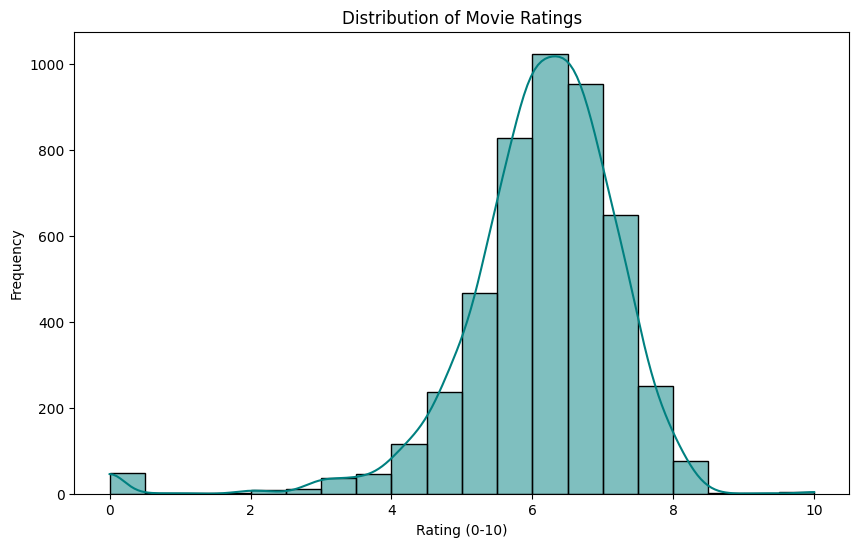

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Movie_Vote'], bins=20, kde=True, color='teal')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating (0-10)')
plt.ylabel('Frequency')
plt.show()

#### 2. Top 10 Movie Geners

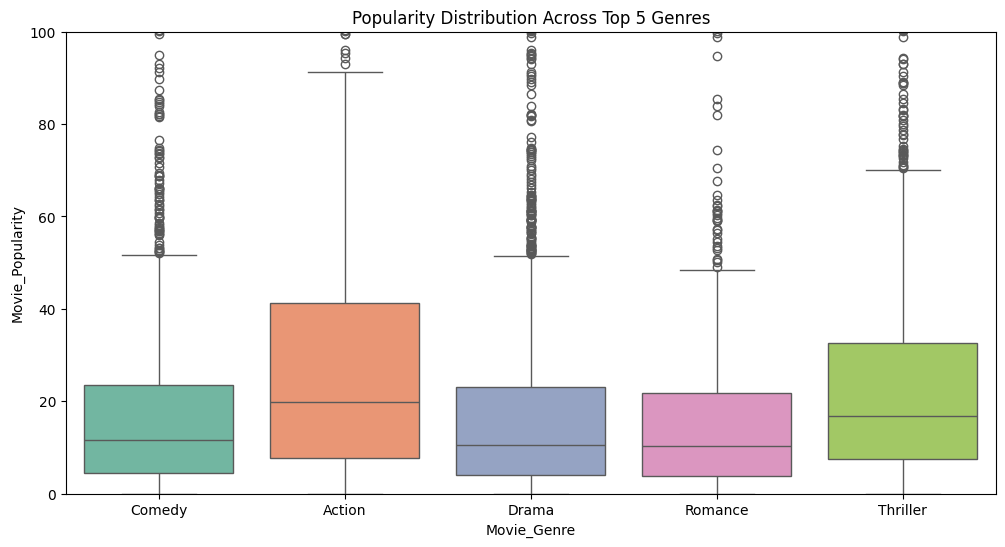

In [13]:
plt.figure(figsize=(12, 6))
top_5_genres = df['Movie_Genre'].str.split().explode().value_counts().head(5).index
df_exploded = df.assign(Movie_Genre=df['Movie_Genre'].str.split()).explode('Movie_Genre')
df_top_5 = df_exploded[df_exploded['Movie_Genre'].isin(top_5_genres)]
sns.boxplot(data=df_top_5, x='Movie_Genre', y='Movie_Popularity', palette='Set2')
plt.title('Popularity Distribution Across Top 5 Genres')
plt.ylim(0, 100)
plt.show()

#### 3. Movie Budget vs. Revenue

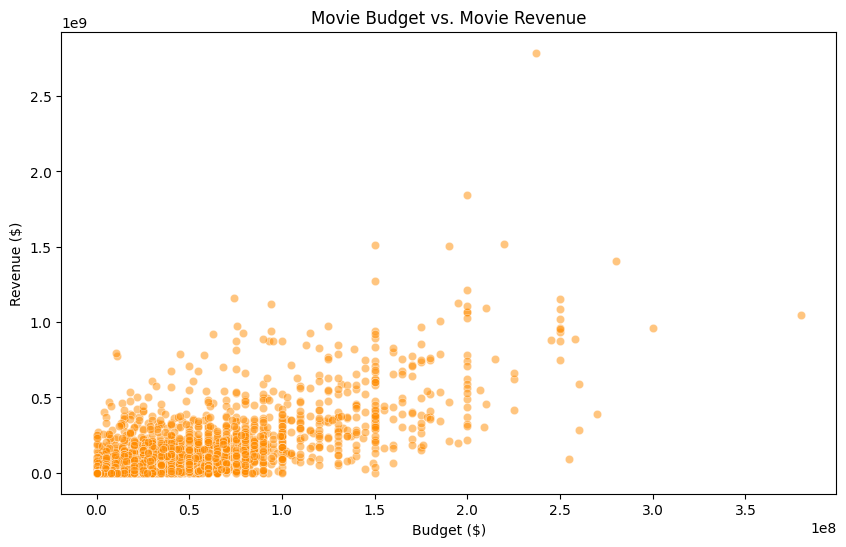

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Movie_Budget', y='Movie_Revenue', alpha=0.5, color='darkorange')
plt.title('Movie Budget vs. Movie Revenue')
plt.xlabel('Budget ($)')
plt.ylabel('Revenue ($)')
plt.show()

#### 4. Top 10 Directors by Movie Count

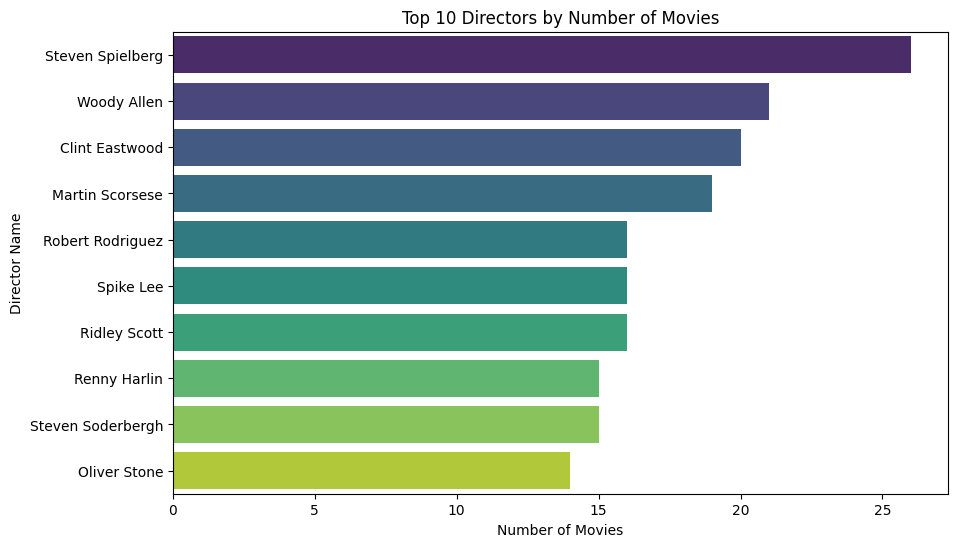

In [15]:
plt.figure(figsize=(10, 6))
top_directors = df[df['Movie_Director'] != '']['Movie_Director'].value_counts().head(10)
sns.barplot(x=top_directors.values, y=top_directors.index, palette='viridis')
plt.title('Top 10 Directors by Number of Movies')
plt.xlabel('Number of Movies')
plt.ylabel('Director Name')
plt.show()

#### 5. Feature Correlation

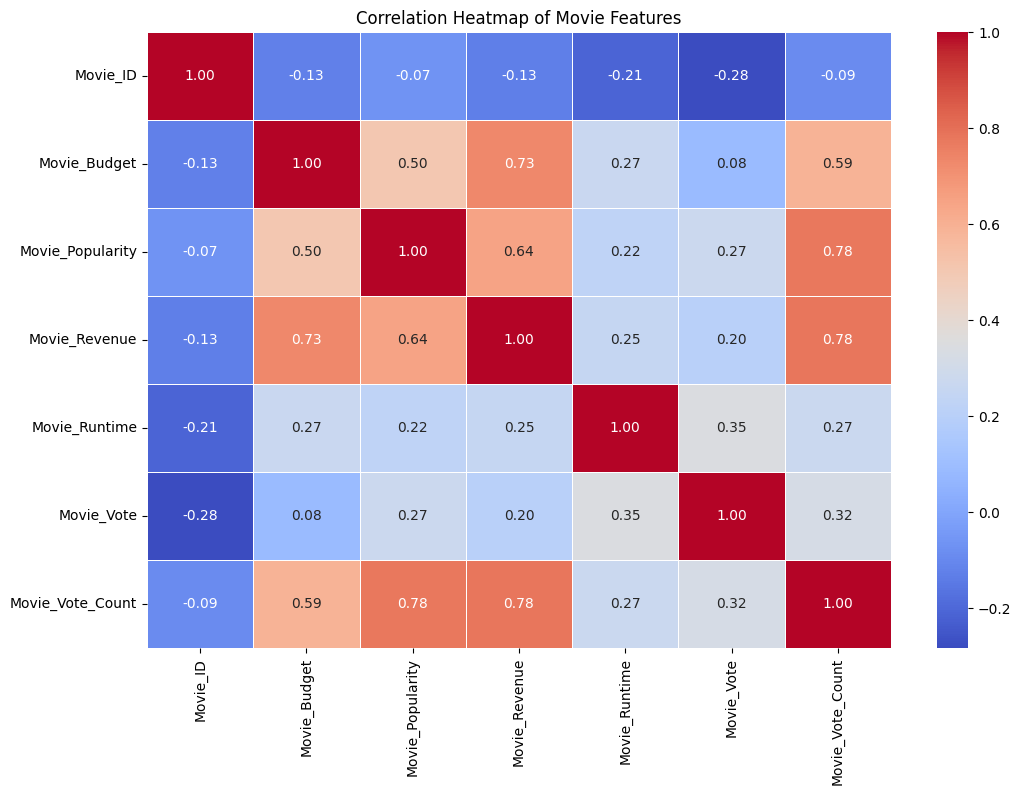

In [16]:
plt.figure(figsize=(12, 8))
numerical_df = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numerical_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Movie Features')
plt.show()

#### check value counts wheather movie hits or flops

In [17]:
df['Is_Hit'] = (df['Movie_Vote'] > 7).astype(int)
print(df['Is_Hit'].value_counts())

Is_Hit
0    3955
1     805
Name: count, dtype: int64


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X = tfidf.fit_transform(df['combined_features'])
y = df['Is_Hit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

========== RANDOM FOREST ==========
              precision    recall  f1-score   support

           0       0.84      1.00      0.92       794
           1       0.92      0.08      0.14       158

    accuracy                           0.85       952
   macro avg       0.88      0.54      0.53       952
weighted avg       0.86      0.85      0.79       952



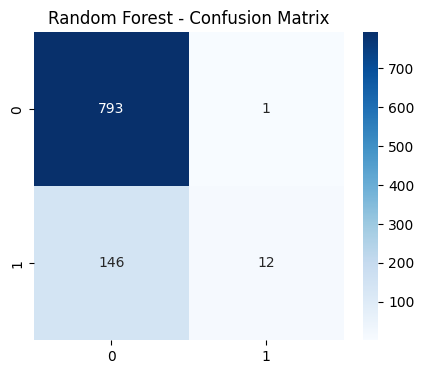

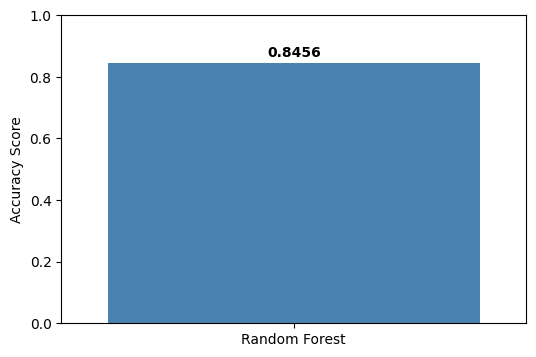

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Train and Predict
rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Report and Heatmap
print("========== RANDOM FOREST ==========")
print(classification_report(y_test, y_pred_rf))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.show()

# Accuracy Bar
plt.figure(figsize=(6,4))
acc_rf = accuracy_score(y_test, y_pred_rf)
sns.barplot(x=["Random Forest"], y=[acc_rf], palette="Blues_d")
plt.ylabel("Accuracy Score")
plt.ylim(0, 1)
plt.text(0, acc_rf + 0.02, f"{acc_rf:.4f}", ha='center', fontweight='bold')
plt.show()

========== GRADIENT BOOSTING ==========
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       794
           1       0.60      0.09      0.16       158

    accuracy                           0.84       952
   macro avg       0.72      0.54      0.54       952
weighted avg       0.80      0.84      0.79       952



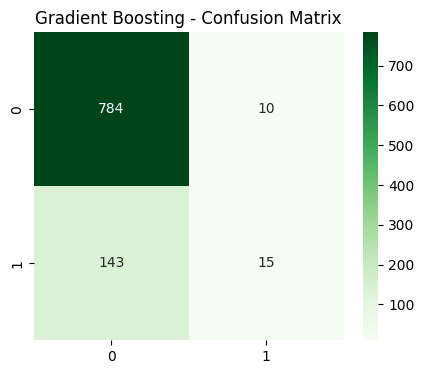

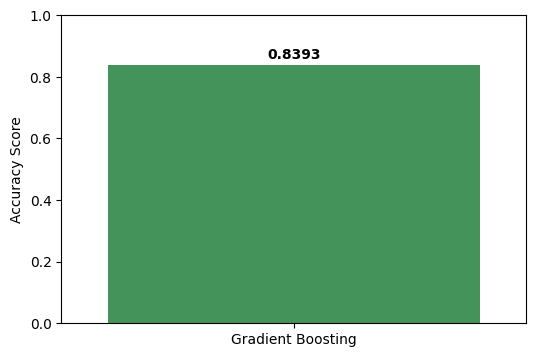

In [20]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Train and Predict
gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

# Report and Heatmap
print("========== GRADIENT BOOSTING ==========")
print(classification_report(y_test, y_pred_gb))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_gb), annot=True, fmt="d", cmap="Greens")
plt.title("Gradient Boosting - Confusion Matrix")
plt.show()

# Accuracy Bar
plt.figure(figsize=(6,4))
acc_gb = accuracy_score(y_test, y_pred_gb)
sns.barplot(x=["Gradient Boosting"], y=[acc_gb], palette="Greens_d")
plt.ylabel("Accuracy Score")
plt.ylim(0, 1)
plt.text(0, acc_gb + 0.02, f"{acc_gb:.4f}", ha='center', fontweight='bold')
plt.show()

========== XGBOOST ==========
              precision    recall  f1-score   support

           0       0.89      0.79      0.84       794
           1       0.33      0.53      0.41       158

    accuracy                           0.75       952
   macro avg       0.61      0.66      0.62       952
weighted avg       0.80      0.75      0.77       952



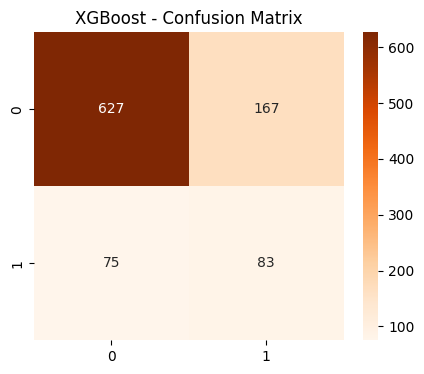

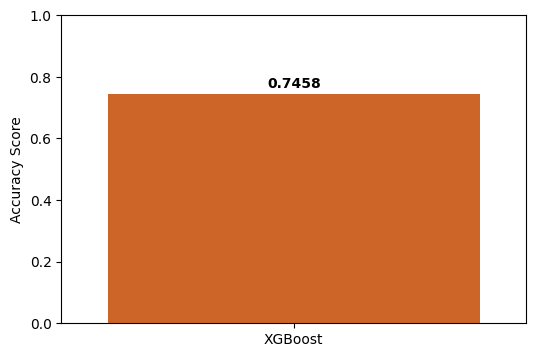

In [21]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize and Train XGBoost
# We use scale_pos_weight=5 because your 'Flops' (0) outnumber 'Hits' (1) by about 5 to 1
xgb_model = XGBClassifier(
    n_estimators=200, 
    learning_rate=0.1, 
    scale_pos_weight=5, 
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# 2. Report and Heatmap
print("========== XGBOOST ==========")
print(classification_report(y_test, y_pred_xgb))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt="d", cmap="Oranges")
plt.title("XGBoost - Confusion Matrix")
plt.show()

# 3. Accuracy Bar
plt.figure(figsize=(6,4))
acc_xgb = accuracy_score(y_test, y_pred_xgb)
sns.barplot(x=["XGBoost"], y=[acc_xgb], palette="Oranges_d")
plt.ylabel("Accuracy Score")
plt.ylim(0, 1)
plt.text(0, acc_xgb + 0.02, f"{acc_xgb:.4f}", ha='center', fontweight='bold')
plt.show()

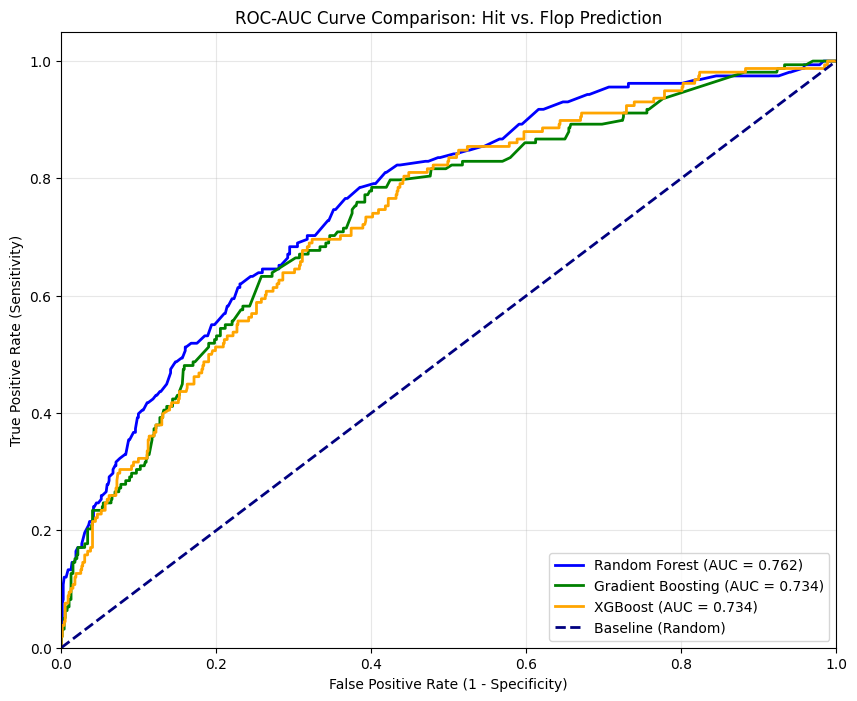

In [22]:
from sklearn.metrics import roc_curve, auc

# Initialize the plot
plt.figure(figsize=(10, 8))

# 1. Random Forest ROC
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc(fpr_rf, tpr_rf):.3f})", color='blue', lw=2)

# 2. Gradient Boosting ROC
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {auc(fpr_gb, tpr_gb):.3f})", color='green', lw=2)

# 3. XGBoost ROC
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc(fpr_xgb, tpr_xgb):.3f})", color='orange', lw=2)

# Plot settings
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Baseline (Random)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC-AUC Curve Comparison: Hit vs. Flop Prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()